# 🎬 LARGE-SCALE OTT PLATFORM ANALYTICS

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.parse
import re

sns.set_theme(style="whitegrid", context="talk")

In [ ]:
plays_dataset = '/content/part-00000-14d5bb3a-9bdc-4bf1-926b-bf7378014e46-c000.csv.gz'
chunk_size = 500000
file_path = '/content/drive/MyDrive/OTT Platform/important_column_dataset.csv'

In [ ]:
important_column = ['utm_source', 'utm_campaign', 'play_duration', 'completed', 'buffer_duration', 'platform', 'autoplay', 'is_premium', 'content_type', 'genre_name', 'hash_play_id']

for i, chunk in enumerate(pd.read_csv(file_path, compression='gzip', chunksize=chunk_size, on_bad_lines='skip', low_memory=False)):
  print(f"processed chunk-{i+1}")
  chunk_subset = chunk[important_column]

  if i == 0:
    chunk_subset.to_csv(file_path, index=False, mode='w')
  else:
    chunk_subset.to_csv(file_path, index=False, mode='a', header=False)

print(f'process completed and saved: {file_path}')

processed chunk-1
processed chunk-2
processed chunk-3
processed chunk-4
processed chunk-5
processed chunk-6
processed chunk-7
processed chunk-8
processed chunk-9
processed chunk-10
processed chunk-11
processed chunk-12
processed chunk-13
processed chunk-14
processed chunk-15
processed chunk-16
processed chunk-17
processed chunk-18
processed chunk-19
processed chunk-20
processed chunk-21
processed chunk-22
processed chunk-23
processed chunk-24
processed chunk-25
processed chunk-26
processed chunk-27
processed chunk-28
processed chunk-29
processed chunk-30
processed chunk-31
processed chunk-32
processed chunk-33
processed chunk-34
processed chunk-35
processed chunk-36
processed chunk-37
processed chunk-38
processed chunk-39
processed chunk-40
processed chunk-41
processed chunk-42
processed chunk-43
processed chunk-44
processed chunk-45
processed chunk-46
processed chunk-47
processed chunk-48
processed chunk-49
processed chunk-50
processed chunk-51
processed chunk-52
processed chunk-53
pr

## 1. Marketing ROI & Acquisition Quality (QVR)
**Pertanyaan Bisnis:** Kampanye marketing (UTM) mana yang mendatangkan audiens dengan *Quality View Rate* (QVR) tertinggi, bukan sekadar *clickbait*?
* Fokus Metrik: `utm_source`, `utm_campaign`, `Total Plays`, `Completed Plays`.

In [ ]:
campaign_total_plays = []
campaign_completed_plays = []

for i, chunk in enumerate(pd.read_csv(file_path, chunksize=chunk_size, on_bad_lines='skip', low_memory=False)):
  print(f"chunk process-{i+1}")

  chunk['utm_source'] = chunk['utm_source'].fillna('').astype(str).str.lower()
  chunk['utm_campaign'] = chunk['utm_campaign'].fillna('').astype(str).str.lower()

  # Decode URL Encoding (Mengubah %20 jadi spasi, %c2%ad dll)
  chunk['utm_campaign'] = chunk['utm_campaign'].apply(lambda x: urllib.parse.unquote(x))
  chunk['utm_campaign'] = chunk['utm_campaign'].str.replace(r'\xad', '', regex=True)

  # Potong Tracking Parameter (Ambil teks SEBELUM tanda '?' dan '#')
  chunk['utm_campaign'] = chunk['utm_campaign'].str.split('?').str[0]
  chunk['utm_campaign'] = chunk['utm_campaign'].str.split('#').str[0]
  chunk['utm_campaign'] = chunk['utm_campaign'].str.strip(' ._')
  chunk['utm_campaign'] = chunk['utm_campaign'].str.replace('vbbnidio-app-share', 'vidio-app-share')

  chunk['utm_source'] = chunk['utm_source'].str.replace('livestreaminng', 'livestreaming')

  chunk['completed'] = chunk['completed'].astype(str).str.lower()
  chunk['completed'] = chunk['completed'].map({'true': 1, 'false': 0}).fillna(0)

  # Gabungkan dulu untuk mencari petunjuk, lalu kita map ke kanal yang bersih
  combined_utm = chunk['utm_source'] + " " + chunk['utm_campaign']

  conditions_source = [
      combined_utm.str.contains(r'\b(ig|instagram)\b|fbig', regex=True),
      combined_utm.str.contains(r'\b(fb|facebook)\b|^fb', regex=True),
      combined_utm.str.contains(r'twitter', regex=True),
      combined_utm.str.contains(r'youtube', regex=True),
      combined_utm.str.contains(r'bbm', regex=True),
      combined_utm.str.contains(r'hdln|gdn|marketing', regex=True),
      combined_utm.str.contains(r'vidio|share', regex=True)
  ]
  choices_source = ['instagram', 'facebook', 'twitter', 'youtube', 'bbm', 'marketing_ads', 'internal_share']

  # Jika tidak ada yang cocok, JANGAN DIBUANG. Pertahankan nilai utm_source aslinya!
  chunk['clean_source'] = np.select(conditions_source, choices_source, default=chunk['utm_source'])

  # 1. Traffic tanpa UTM Source diubah menjadi 'organic'
  chunk['clean_source'] = chunk['clean_source'].replace('', 'organic')

  # B. Standarisasi Campaign (Membuang prefix source yang menempel)
  chunk['clean_campaign'] = chunk['utm_campaign']

  # Hapus kata 'fb', 'twitter', 'youtube' jika berada di AWAL nama campaign
  chunk['clean_campaign'] = chunk['clean_campaign'].str.replace(r'^(fb|twitter|youtube)', '', regex=True)

  # Ganti spasi dengan underscore agar formatnya seragam
  chunk['clean_campaign'] = chunk['clean_campaign'].str.replace(r'\s+', '_', regex=True)

  # Jika setelah dicuci campaign-nya jadi kosong, beri label 'general'
  chunk['clean_campaign'] = chunk['clean_campaign'].replace('', 'general')

  # Menghapus akhiran _ctw, _engagement, _vip, dan ctw (tanpa underscore)
  chunk['clean_campaign'] = chunk['clean_campaign'].str.replace(r'(_ctw_vip|_ctw|_engagement|_vip|ctw)$', '', regex=True)

  # Menyeragamkan prefix 'video_' menjadi genrenya saja (video_entertainment -> entertainment)
  chunk['clean_campaign'] = chunk['clean_campaign'].str.replace(r'^video_', '', regex=True)

  chunk.loc[chunk['clean_campaign'].str.contains('share', na=False), 'clean_campaign'] = 'user_share'
  chunk.loc[chunk['clean_campaign'].str.contains(r'^ig|^instagram', regex=True, na=False), 'clean_campaign'] = 'instagram_promo'

  campaign_total_plays.append(chunk.groupby(['clean_source', 'clean_campaign'])['hash_play_id'].count())
  campaign_completed_plays.append(chunk.groupby(['clean_source', 'clean_campaign'])['completed'].sum())

print("Chunking process completed")

chunk process-1


/tmp/ipython-input-179/1324575594.py:45: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  combined_utm.str.contains(r'\b(ig|instagram)\b|fbig', regex=True),
/tmp/ipython-input-179/1324575594.py:46: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  combined_utm.str.contains(r'\b(fb|facebook)\b|^fb', regex=True),


chunk process-2


/tmp/ipython-input-179/1324575594.py:45: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  combined_utm.str.contains(r'\b(ig|instagram)\b|fbig', regex=True),
/tmp/ipython-input-179/1324575594.py:46: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  combined_utm.str.contains(r'\b(fb|facebook)\b|^fb', regex=True),


chunk process-3


...

chunk process-110


/tmp/ipython-input-179/1324575594.py:45: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  combined_utm.str.contains(r'\b(ig|instagram)\b|fbig', regex=True),
/tmp/ipython-input-179/1324575594.py:46: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  combined_utm.str.contains(r'\b(fb|facebook)\b|^fb', regex=True),


chunk process-111


/tmp/ipython-input-179/1324575594.py:45: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  combined_utm.str.contains(r'\b(ig|instagram)\b|fbig', regex=True),
/tmp/ipython-input-179/1324575594.py:46: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  combined_utm.str.contains(r'\b(fb|facebook)\b|^fb', regex=True),


Chunking process completed


In [ ]:
df_campaign = pd.DataFrame({
    'Total_Plays': pd.concat(campaign_total_plays).groupby(level=[0, 1]).sum(),
    'Completed_Plays': pd.concat(campaign_completed_plays).groupby(level=[0, 1]).sum(),
}).reset_index()

df_campaign['QVR%'] = np.round((df_campaign['Completed_Plays'] / df_campaign['Total_Plays']) * 100, 2)
df_campaign_sorted = df_campaign[df_campaign['Total_Plays'] > 500].sort_values(by='QVR%', ascending=False).reset_index(drop=True)
df_campaign_sorted

,clean_source,clean_campaign,Total_Plays,Completed_Plays,QVR%
0,instagram,instagram_promo,4068,794.0,19.52
1,facebook,general,1594,283.0,17.75
2,organic,general,55001847,8604710.0,15.64
3,internal_share,user_share,13781,1506.0,10.93
4,partnership,kobe_bryant,759,64.0,8.43
5,youtube,general,50215,1392.0,2.77


/tmp/ipython-input-179/578353286.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_campaign, x='QVR%', y='Campaign_Name', palette='viridis')


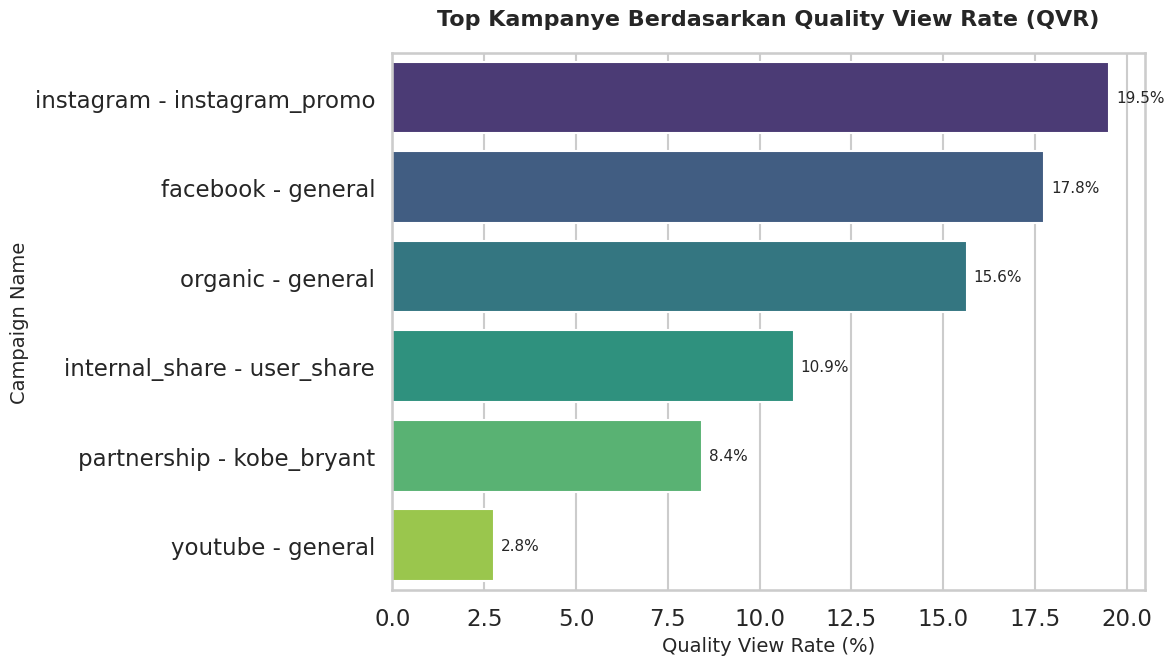

In [ ]:
top_campaign = df_campaign_sorted.copy()
top_campaign['Campaign_Name'] = top_campaign['clean_source'] + ' - ' + top_campaign['clean_campaign']

plt.figure(figsize=(12, 7))
ax = sns.barplot(data=top_campaign, x='QVR%', y='Campaign_Name', palette='viridis')

plt.title('Top Kampanye Berdasarkan Quality View Rate (QVR)', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Quality View Rate (%)', fontsize=14)
plt.ylabel('Campaign Name', fontsize=14)

for p in ax.patches:
    ax.annotate(f'{p.get_width():.1f}%',
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=11)

plt.tight_layout()
plt.show()

### Business Insight

**Observasi**

- Saluran media sosial Meta mendominasi kualitas akuisisi. Kampanye instagram_promo berada di peringkat pertama dengan tingkat konversi menonton hingga tamat (QVR) sebesar 19.5%, disusul rapat oleh kampanye facebook - general di angka 17.8%.
- Trafik yang datang secara gratis atau Word of Mouth menunjukkan performa luar biasa. Saluran `organic - general` meraih QVR 15.6%, dan fitur share dari sesama pengguna (`internal_share - user_share`) menyumbang 10.9%.
- Sebaliknya, kampanye dari `youtube - general` menempati posisi terendah di Top 6 ini dengan QVR hanya 2.8% (mayoritas audiens dari saluran ini hanya mengeklik lalu segera kabur/ bounce).


**Insight**

- Pengguna yang datang dari Instagram dan Facebook memiliki niat menonton (intensi) yang sangat selaras dengan konten yang ditawarkan OTT. Mereka bukan sekadar korban clickbait.
- Tingginya QVR pada trafik organik dan internal share membuktikan bahwa ketika seorang pengguna merekomendasikan tontonan ke teman/keluarganya (via link share), teman tersebut hampir pasti akan menontonnya sampai habis. Ini adalah bentuk marketing gratis yang paling ampuh.
- Trafik dari YouTube kemungkinan besar berasal dari klik iklan yang tidak sengaja (salah pencet) atau iklan yang tidak relevan dengan ekspektasi penonton, sehingga tingkat penyelesaian tayangannya sangat hancur.

**Rekomendasi**
- Alokasikan ulang budget iklan dari kampanye dengan QVR di bawah 5% untuk diinvestasikan lebih besar pada kampanye teratas.
- Lakukan analisa materi iklan pada top 1 kampanye untuk direplikasi formatnya pada kampanye selanjutnya.
- Karena fitur `internal_share` mendatangkan penonton dengan kualitas tinggi (10,9%), permudah *User Experience* (UX) untuk membagikan konten. Bisa tambahkan tombol "Share ke WA/IG Story" yang lebih besar dan menarik (misalnya adakan sistem *reward* atau koin) setiap kali pengguna selesai menonton sebuah film.

## 2. Technical UX & Churn Analysis (The Drop-off Cliff)
**Pertanyaan Bisnis:** Seberapa signifikan dampak latensi (durasi *buffering*) terhadap tingkat retensi dan penyelesaian tayangan pengguna?
* Fokus Metrik: `buffer_duration`, `Total Plays`, `Completed Plays`, `Platform`.

In [ ]:
buffer_total_plays = []
buffer_completed_plays = []

for i, chunk in enumerate(pd.read_csv(file_path, chunksize=chunk_size, on_bad_lines='skip', low_memory=False)):
  print(f"processed chunk-{i+1}")

  chunk = chunk.dropna(subset='platform')
  if chunk.empty: continue

  chunk['buffer_duration'] = chunk['buffer_duration'].astype(float).fillna(0)
  chunk['completed'] = chunk['completed'].astype(str).str.lower()
  chunk['completed'] = chunk['completed'].map({'true': 1, 'false': 0}).fillna(0)

  bins = [-1, 1, 6, 16, 30, float('inf')]
  labels = ['No Buffer', 'Low', 'Mid', 'High', 'Unwatchable']
  chunk['buffer_category'] = pd.cut(chunk['buffer_duration'], bins=bins, labels=labels)

  buffer_total_plays.append(chunk.groupby('buffer_category')['hash_play_id'].count())
  buffer_completed_plays.append(chunk.groupby('buffer_category')['completed'].sum())

print("Chunking process completed")


processed chunk-1


/tmp/ipython-input-864/2040554752.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  campaign_total_plays.append(chunk.groupby('buffer_category')['hash_play_id'].count())
/tmp/ipython-input-864/2040554752.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  campaign_completed_plays.append(chunk.groupby('buffer_category')['completed'].sum())


processed chunk-2


/tmp/ipython-input-864/2040554752.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  campaign_total_plays.append(chunk.groupby('buffer_category')['hash_play_id'].count())
/tmp/ipython-input-864/2040554752.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  campaign_completed_plays.append(chunk.groupby('buffer_category')['completed'].sum())


processed chunk-3


...

/tmp/ipython-input-864/2040554752.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  campaign_total_plays.append(chunk.groupby('buffer_category')['hash_play_id'].count())
/tmp/ipython-input-864/2040554752.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  campaign_completed_plays.append(chunk.groupby('buffer_category')['completed'].sum())


processed chunk-110


/tmp/ipython-input-864/2040554752.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  campaign_total_plays.append(chunk.groupby('buffer_category')['hash_play_id'].count())
/tmp/ipython-input-864/2040554752.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  campaign_completed_plays.append(chunk.groupby('buffer_category')['completed'].sum())


processed chunk-111
Chunking process completed


/tmp/ipython-input-864/2040554752.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  campaign_total_plays.append(chunk.groupby('buffer_category')['hash_play_id'].count())
/tmp/ipython-input-864/2040554752.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  campaign_completed_plays.append(chunk.groupby('buffer_category')['completed'].sum())


In [ ]:
df_buffer = pd.DataFrame({
    'Total_Plays': pd.concat(buffer_total_plays).groupby(level=0).sum(),
    'Completed_Plays': pd.concat(buffer_completed_plays).groupby(level=0).sum(),
}).reset_index()

df_buffer['Completion Rate%'] = np.round((df_buffer['Completed_Plays'] / df_buffer['Total_Plays']) * 100, 2)
df_buffer_sorted = df_buffer.sort_values(by='Completion Rate%', ascending=False).reset_index()
df_buffer_sorted.drop(columns='index', inplace=True)
df_buffer_sorted

/tmp/ipython-input-864/2505071991.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  'Total_Plays': pd.concat(campaign_total_plays).groupby(level=0).sum(),
/tmp/ipython-input-864/2505071991.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  'Completed_Plays': pd.concat(campaign_completed_plays).groupby(level=0).sum(),


,buffer_category,Total_Plays,Completed_Plays,Completion Rate%
0,No Buffer,27203336,5056034.0,18.59
1,Low,13737892,1909079.0,13.90
2,Mid,5315069,736283.0,13.85
3,High,1960775,270382.0,13.79
4,Unwatchable,6856487,637155.0,9.29


In [ ]:
buffer_detail_total_plays = []
buffer_detail_completed_plays = []

for i, chunk in enumerate(pd.read_csv(file_path, chunksize=chunk_size, on_bad_lines='skip', low_memory=False)):
  print(f"processed chunk-{i+1}")

  chunk = chunk.dropna(subset='platform')
  if chunk.empty: continue

  chunk['buffer_duration'] = chunk['buffer_duration'].astype(float).fillna(0)
  chunk['completed'] = chunk['completed'].astype(str).str.lower()
  chunk['completed'] = chunk['completed'].map({'true': 1, 'false': 0}).fillna(0)

  bins = [-1, 1, 6, 16, 30, float('inf')]
  labels = ['No Buffer', 'Low', 'Mid', 'High', 'Unwatchable']
  chunk['buffer_category'] = pd.cut(chunk['buffer_duration'], bins=bins, labels=labels)

  buffer_detail_total_plays.append(chunk.groupby(['platform', 'buffer_category'])['hash_play_id'].count())
  buffer_detail_completed_plays.append(chunk.groupby(['platform', 'buffer_category'])['completed'].sum())

print("Chunking process completed")


processed chunk-1


/tmp/ipython-input-179/399184221.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  buffer_detail_total_plays.append(chunk.groupby(['platform', 'buffer_category'])['hash_play_id'].count())
/tmp/ipython-input-179/399184221.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  buffer_detail_completed_plays.append(chunk.groupby(['platform', 'buffer_category'])['completed'].sum())


processed chunk-2


/tmp/ipython-input-179/399184221.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  buffer_detail_total_plays.append(chunk.groupby(['platform', 'buffer_category'])['hash_play_id'].count())
/tmp/ipython-input-179/399184221.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  buffer_detail_completed_plays.append(chunk.groupby(['platform', 'buffer_category'])['completed'].sum())


processed chunk-3


...

/tmp/ipython-input-179/399184221.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  buffer_detail_total_plays.append(chunk.groupby(['platform', 'buffer_category'])['hash_play_id'].count())
/tmp/ipython-input-179/399184221.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  buffer_detail_completed_plays.append(chunk.groupby(['platform', 'buffer_category'])['completed'].sum())


processed chunk-110


/tmp/ipython-input-179/399184221.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  buffer_detail_total_plays.append(chunk.groupby(['platform', 'buffer_category'])['hash_play_id'].count())
/tmp/ipython-input-179/399184221.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  buffer_detail_completed_plays.append(chunk.groupby(['platform', 'buffer_category'])['completed'].sum())


processed chunk-111
Chunking process completed


/tmp/ipython-input-179/399184221.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  buffer_detail_total_plays.append(chunk.groupby(['platform', 'buffer_category'])['hash_play_id'].count())
/tmp/ipython-input-179/399184221.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  buffer_detail_completed_plays.append(chunk.groupby(['platform', 'buffer_category'])['completed'].sum())


In [ ]:
df_buffer = pd.DataFrame({
    'Total_Plays': pd.concat(buffer_detail_total_plays).groupby(level=[0, 1]).sum(),
    'Completed_Plays': pd.concat(buffer_detail_completed_plays).groupby(level=[0, 1]).sum(),
}).reset_index()

df_buffer['Completion Rate%'] = np.round((df_buffer['Completed_Plays'] / df_buffer['Total_Plays']) * 100, 2)

/tmp/ipython-input-179/3009907412.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  'Total_Plays': pd.concat(buffer_detail_total_plays).groupby(level=[0, 1]).sum(),
/tmp/ipython-input-179/3009907412.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  'Completed_Plays': pd.concat(buffer_detail_completed_plays).groupby(level=[0, 1]).sum(),


,platform,buffer_category,Total_Plays,Completed_Plays,Completion Rate%
0,app-android,No Buffer,2950301,12824.0,0.43
1,app-android,Low,4883210,331550.0,6.79
2,app-android,Mid,2761210,371879.0,13.47
3,app-android,High,1098524,178441.0,16.24
4,app-android,Unwatchable,2197639,430356.0,19.58
5,app-ios,No Buffer,878719,23745.0,2.70
6,app-ios,Low,54723,16553.0,30.25
7,app-ios,Mid,22640,7534.0,33.28
8,app-ios,High,11666,4030.0,34.54
9,app-ios,Unwatchable,28446,10860.0,38.18


In [ ]:
df_pivot = df_buffer.pivot(index='platform', columns='buffer_category', values='Completion Rate%')
df_pivot = df_pivot.sort_values(by='No Buffer', ascending=False)
df_pivot

buffer_category,No Buffer,Low,Mid,High,Unwatchable
platform,,,,,
web-mobile,23.21,17.95,13.74,9.65,8.52
web-desktop,7.47,18.09,15.21,11.86,15.87
tv-android,4.45,20.50,35.95,43.24,0.18
tv-tizen,3.75,0.01,0.02,0.00,0.00
app-ios,2.70,30.25,33.28,34.54,38.18
app-android,0.43,6.79,13.47,16.24,19.58
tv-webos,0.00,19.82,16.28,6.67,11.76


<Figure size 1200x600 with 0 Axes>

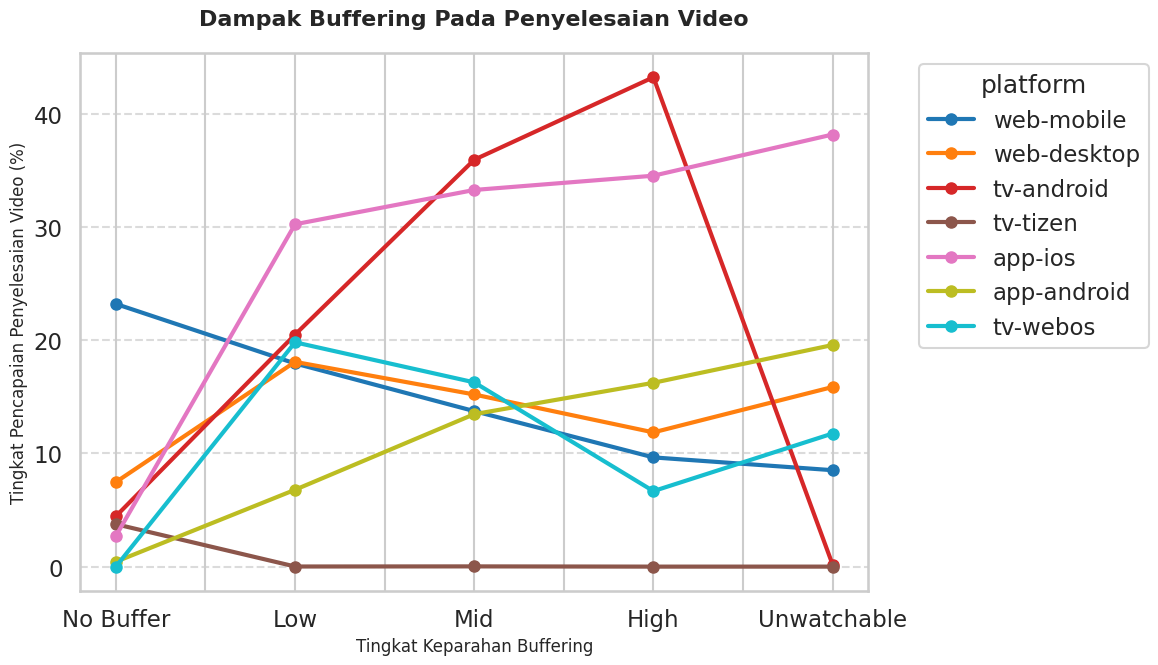

In [ ]:
df_buffer_trend = df_pivot.T

plt.figure(figsize=(12, 6))

df_buffer_trend.plot(kind='line', marker='o', linewidth=3, markersize=8, figsize=(12, 7), cmap='tab10')

plt.title('Dampak Buffering Pada Penyelesaian Video', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Tingkat Keparahan Buffering', fontsize=12)
plt.ylabel('Tingkat Pencapaian Penyelesaian Video (%)', fontsize=12)
plt.legend(title='platform', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### **Business Insight**

**Observasi**:
- Terdapat dua pola bertolak belakang berdasarkan platform. Pada `web-mobile`, terlihat tren normal. Tingkat penyelesaian terus menurun secara bertahap dari 23% ke 8% seiring memburuknya *buffering*.
- Akan tetapi, pada platform aplikasi dan TV (`tv-android`, `app-ios`, `app-android`), *Completion Rate* justru terlihat naik beriringan dengan naiknya durasi buffer, hingga mencapai puncaknya di kategori 'High' (bahkan `tv-android` menyentuh >40%), sebelum akhirnya terjun bebas ke angka 0% di titik 'Unwatchable'
- Platform seperti `tv-tizen` menunjukkan anomali, di mana tingkat penyelesaian langsung turun ke titik 0% begitu menyentuh kategori 'Low'

**Insight**
- Naiknya grafik pada aplikasi dan TV bukan tanda *user* menikmati *buffering*. INi terjadi karena pengguna Smart TV dan App biasanya menonton konten berdurasi sangat panjang (Film / Series). Semakin lama mereka sanggup menonton sampai tamat, semakin besar akumulasi total detik buffer yang dikumpulkan.
- Sebaliknya, `web-mobile` didominasi konten pendek (berita/klip). Bagi menonton web, *buffer* 5 detik di video berdurasi 1 menit sudah terasa sangat parah, sampai membuat mereka langsung *bounce* (kabur).
- Terjun bebasnya `tv-android` di kategori 'Unwatchable' mengonfirmasi bahwa sehebat apapun niat user menonton film panjang, ada Batas Kritis Frustrasi yang membuat mereka akhirnya menyerah.

**Rekomendasi**
1. Evaluasi metrik *buffering* agar bisa lebih adil lagi dengan mengubah dari 'detik' ubah menjadi 'buffer ratio' (Persentase *buffer* terhadap total durasi tontonan). Ini akan menormalisasi perbandingan antara video pendek dan video panjang.
2. Periksa aplikasi di `tv-tizen` (Samsung). Metrik pada aplikasi sepertinya tidak berjalan semestinya seperti yang terlihat saat terjadi *buffer* (Low) kemungkinan mengindikasikan adanya *bug* di mana aplikasi gagal *resume* (*video error/force close*) setiap kali terjadi sedikit fluktuasi jaringan.

## 3. Product Feature Effectiveness (Autoplay Evaluation)
**Pertanyaan Bisnis:** Apakah fitur *Autoplay* terbukti efektif meningkatkan *engagement*, atau justru merusak UX dan menyumbang *Bounce Rate* yang tinggi?
* Fokus Metrik: `autoplay`, `play_duration`, `Bounce Rate`, `Average Duration`.

In [ ]:
autoplay_total_plays = []
autoplay_total_completed = []
autoplay_total_duration = []
autoplay_total_bounce = []

for i, chunk in enumerate(pd.read_csv(file_path, chunksize=chunk_size, on_bad_lines='skip', low_memory=False)):
  print(f"processed chunk-{i+1}")
  chunk['autoplay'] = chunk['autoplay'].astype(str).str.lower()
  chunk['autoplay'] = chunk['autoplay'].map({'true': 1, 'false': 0}).fillna(0)

  chunk['play_duration'] = pd.to_numeric(chunk['play_duration'], errors='coerce')
  chunk = chunk[chunk['play_duration'] > 0]

  chunk['completed'] = chunk['completed'].astype(str).str.lower()
  chunk['completed'] = chunk['completed'].map({'true': 1, 'false': 0}).fillna(0)

  chunk['is_bounce'] = np.where((chunk['play_duration'] <= 15) & (chunk['completed'] == 0), 1, 0)

  autoplay_total_plays.append(chunk.groupby('autoplay')['hash_play_id'].count())
  autoplay_total_completed.append(chunk.groupby('autoplay')['completed'].sum())
  autoplay_total_duration.append(chunk.groupby('autoplay')['play_duration'].sum())
  autoplay_total_bounce.append(chunk.groupby('autoplay')['is_bounce'].sum())

print("Chunking process completed")

processed chunk-1


/tmp/ipython-input-274/168970204.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk['completed'] = chunk['completed'].astype(str).str.lower()
/tmp/ipython-input-274/168970204.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk['completed'] = chunk['completed'].map({'true': 1, 'false': 0}).fillna(0)
/tmp/ipython-input-274/168970204.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the 

processed chunk-2


/tmp/ipython-input-274/168970204.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk['completed'] = chunk['completed'].astype(str).str.lower()
/tmp/ipython-input-274/168970204.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk['completed'] = chunk['completed'].map({'true': 1, 'false': 0}).fillna(0)
/tmp/ipython-input-274/168970204.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the 

processed chunk-3


...

/tmp/ipython-input-274/168970204.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk['completed'] = chunk['completed'].astype(str).str.lower()
/tmp/ipython-input-274/168970204.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk['completed'] = chunk['completed'].map({'true': 1, 'false': 0}).fillna(0)
/tmp/ipython-input-274/168970204.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the 

processed chunk-110


/tmp/ipython-input-274/168970204.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk['completed'] = chunk['completed'].astype(str).str.lower()
/tmp/ipython-input-274/168970204.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk['completed'] = chunk['completed'].map({'true': 1, 'false': 0}).fillna(0)
/tmp/ipython-input-274/168970204.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the 

processed chunk-111
Chunking process completed


/tmp/ipython-input-274/168970204.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk['completed'] = chunk['completed'].astype(str).str.lower()
/tmp/ipython-input-274/168970204.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk['completed'] = chunk['completed'].map({'true': 1, 'false': 0}).fillna(0)
/tmp/ipython-input-274/168970204.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the 

In [ ]:
df_bounce = pd.DataFrame({
    'Total_Plays': pd.concat(autoplay_total_plays).groupby(level=0).sum(),
    'Total_Completed': pd.concat(autoplay_total_completed).groupby(level=0).sum(),
    'Total_Duration': pd.concat(autoplay_total_duration).groupby(level=0).sum(),
    'Total_Bounce': pd.concat(autoplay_total_bounce).groupby(level=0).sum(),
}).reset_index()

df_bounce['Completion Rate (%)'] = np.round((df_bounce['Total_Completed'] / df_bounce['Total_Plays']) * 100, 2)
df_bounce['Average Duration'] = np.round(df_bounce['Total_Duration'] / df_bounce['Total_Plays'], 2)
df_bounce['Bounce Rate (%)'] = np.round((df_bounce['Total_Bounce'] / df_bounce['Total_Plays']) * 100, 2)
df_bounce['autoplay'] = df_bounce['autoplay'].map({0: 'Manual Play', 1: 'Autoplay'})
df_bounce

,autoplay,Total_Plays,Total_Completed,Total_Duration,Total_Bounce,Completion Rate (%),Average Duration,Bounce Rate (%)
0,Manual Play,37131104,6502929.0,1.775890e+10,6404551,17.51,478.28,17.25
1,Autoplay,4882337,2106032.0,6.955264e+09,521674,43.14,1424.58,10.68


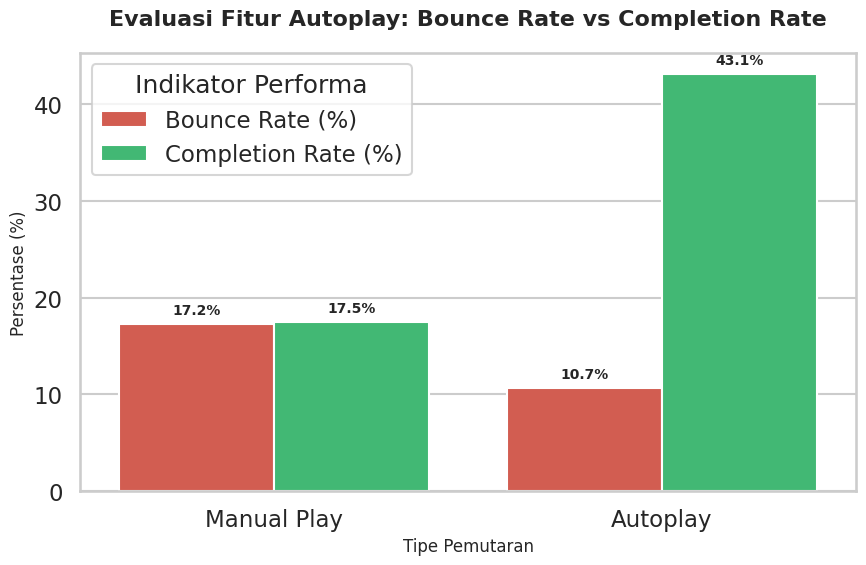

In [ ]:
df_bounce_melted = df_bounce.melt(id_vars='autoplay',
                                  value_vars=['Bounce Rate (%)', 'Completion Rate (%)'],
                                  var_name='Metrik',
                                  value_name='Persentase')

plt.figure(figsize=(9, 6))
ax = sns.barplot(data=df_bounce_melted, x='autoplay', y='Persentase', hue='Metrik', palette=['#e74c3c', '#2ecc71'])

plt.title('Evaluasi Fitur Autoplay: Bounce Rate vs Completion Rate', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Tipe Pemutaran', fontsize=12)
plt.ylabel('Persentase (%)', fontsize=12)

for p in ax.patches[:4]:
  ax.annotate(f"{p.get_height():.1f}%",
              (p.get_x() + p.get_width() / 2., p.get_height()),
              ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontsize=10, fontweight='bold')

plt.legend(title='Indikator Performa')
plt.tight_layout()
plt.show()


### Business Insight
**Observasi**
- Data dengan telak menunjukkan bahwa fitur *Autoplay* justru bekerja sangat efektif.
- Tingkat penyelesaian video (*Completion Rate*) pada *Autoplay* melesat jauh di angka 43.1%, berbanding terbalik dengan *Manual Play* yang hanya mencatat 17.5%.
- Kekhawatiran soal Bounce Rate ternyata tidak terbukti. Penonton yang mengalami *Autoplay* justru memiliki tingkat kabur di bawah 15 detik yang lebih rendah (10.7%) dibandingkan penonton yang mengeklik sendiri (*Manual Play* sebesar 17.2%).

**Insight**
- Audiens OTT sangat menyukai pengalaman menonton yang mengalir (*seamless*). *Autoplay* biasanya terpicu pada akhir episode (untuk sinetron/anime berseri) atau pada *playlist* kurasi. Saat *Autoplay* berjalan, pengguna sudah dalam posisi rileks dan cenderung terus menonton episode berikutnya tanpa henti.
- Mengapa Bounce Rate *Manual Play* lebih tinggi? Karena saat pengguna mengeklik sendiri, mereka sedang bereksperimen. Jika dalam 10 detik pertama video tersebut dirasa kurang menarik atau judulnya tidak sesuai ekspektasi (*clickbait*), mereka tidak segan untuk langsung mematikannya.

**Rekomendasi**
- Pertahankan dan optimalkan algoritma *Autoplay*! Fitur ini adalah senjata utama untuk meningkatkan metrik Watch Time di OTT. Segera perluas penerapan *Autoplay* pintar (seperti memutar trailer singkat saat user menyorot poster film) di halaman utama aplikasi.
- Karena penonton *Manual Play* memiliki tingkat *drop-off* awal yang lebih tinggi, segera optimalkan akurasi *Thumbnail* (gambar mini) dan *Preview Snippet*. Pastikan gambar yang diklik sesuai dengan isi video agar pengguna tidak merasa tertipu dan langsung bounce.

## 4. Content Monetization Strategy (Binge-Worthy Analysis)
**Pertanyaan Bisnis:** Di segmen pengguna berbayar (*Premium*), *Mega-Genre* apa yang memiliki tingkat *binge-watching* (kecanduan menonton hingga tamat) tertinggi dibandingkan pengguna gratis?
* Fokus Metrik: `is_premium`, `genre_name`, `Total Plays`, `Completion Rate (%)`.

In [ ]:
premium_total_plays = []
premium_total_completed = []

junk_tags = ['newly added', 'top 10 this week', 'popular', 'xl home', 'null', '"']

print("Memulai proses dengan metode EXPLODE...")

for i, chunk in enumerate(pd.read_csv(file_path, chunksize=chunk_size, on_bad_lines='skip', low_memory=False)):
    print(f"processed chunk-{i+1}")

    chunk = chunk.dropna(subset=['is_premium'])
    chunk['is_premium'] = chunk['is_premium'].astype(str).str.lower().map({'true': 1, 'false': 0})
    chunk['content_type'] = chunk['content_type'].astype(str).str.lower()

    chunk['genre_name'] = chunk['genre_name'].fillna('unknown_genre').astype(str).str.lower()

    for tag in junk_tags:
        chunk['genre_name'] = chunk['genre_name'].str.replace(tag, '', regex=False)

    chunk['genre_name'] = chunk['genre_name'].str.split(',')
    chunk = chunk.explode('genre_name')
    chunk['genre_name'] = chunk['genre_name'].str.strip()
    chunk = chunk[chunk['genre_name'] != '']

    chunk['completed'] = chunk['completed'].astype(str).str.lower().map({'true': 1, 'false': 0}).fillna(0)

    premium_total_plays.append(chunk.groupby(['is_premium', 'content_type', 'genre_name'])['hash_play_id'].count())
    premium_total_completed.append(chunk.groupby(['is_premium', 'content_type', 'genre_name'])['completed'].sum())

print("Chunking process completed!")



Memulai proses dengan metode EXPLODE...
processed chunk-1
processed chunk-2


/tmp/ipython-input-179/2151090513.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk['is_premium'] = chunk['is_premium'].astype(str).str.lower().map({'true': 1, 'false': 0})
/tmp/ipython-input-179/2151090513.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk['content_type'] = chunk['content_type'].astype(str).str.lower()
/tmp/ipython-input-179/2151090513.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] 

processed chunk-3


/tmp/ipython-input-179/2151090513.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk['is_premium'] = chunk['is_premium'].astype(str).str.lower().map({'true': 1, 'false': 0})
/tmp/ipython-input-179/2151090513.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk['content_type'] = chunk['content_type'].astype(str).str.lower()
/tmp/ipython-input-179/2151090513.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] 

processed chunk-4
processed chunk-5
processed chunk-6


...

processed chunk-87
processed chunk-88
processed chunk-89
processed chunk-90
processed chunk-91
processed chunk-92
processed chunk-93
processed chunk-94
processed chunk-95


/tmp/ipython-input-179/2151090513.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk['is_premium'] = chunk['is_premium'].astype(str).str.lower().map({'true': 1, 'false': 0})
/tmp/ipython-input-179/2151090513.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk['content_type'] = chunk['content_type'].astype(str).str.lower()
/tmp/ipython-input-179/2151090513.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] 

processed chunk-96
processed chunk-97
processed chunk-98
processed chunk-99
processed chunk-100
processed chunk-101


/tmp/ipython-input-179/2151090513.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk['is_premium'] = chunk['is_premium'].astype(str).str.lower().map({'true': 1, 'false': 0})
/tmp/ipython-input-179/2151090513.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk['content_type'] = chunk['content_type'].astype(str).str.lower()
/tmp/ipython-input-179/2151090513.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] 

processed chunk-102
processed chunk-103
processed chunk-104
processed chunk-105
processed chunk-106
processed chunk-107
processed chunk-108
processed chunk-109
processed chunk-110
processed chunk-111
Chunking process completed!


In [ ]:
df_content = pd.DataFrame({
    'Total_Plays': pd.concat(premium_total_plays).groupby(level=[0, 1, 2]).sum(),
    'Total_Completed': pd.concat(premium_total_completed).groupby(level=[0, 1, 2]).sum(),
}).reset_index()

df_premium = df_content[(df_content['is_premium'] == 1) & (df_content['Total_Plays'] > 500)].copy()
df_premium['Completion Rate (%)'] = np.round((df_premium['Total_Completed'] / df_premium['Total_Plays']) * 100, 2)
df_premium = df_premium.sort_values(by=['Completion Rate (%)', 'Total_Plays'], ascending=False).reset_index(drop=True)

df_free = df_content[(df_content['is_premium'] == 0) & (df_content['Total_Plays'] > 500)].copy()
df_free['Completion Rate (%)'] = np.round((df_free['Total_Completed'] / df_free['Total_Plays']) * 100, 2)
df_free = df_free.sort_values(by=['Completion Rate (%)', 'Total_Plays'], ascending=False).reset_index(drop=True)

df_premium.head(10)

,is_premium,content_type,genre_name,Total_Plays,Total_Completed,Completion Rate (%)
0,1,vod,kids,2026,1129.0,55.73
1,1,vod,animation,2560,1191.0,46.52
2,1,vod,unknown_genre,2372,1097.0,46.25
3,1,vod,korean series,64018,27051.0,42.26
4,1,vod,romance,80197,31603.0,39.41
5,1,vod,historical fiction,2698,995.0,36.88
6,1,vod,drama,227564,83701.0,36.78
7,1,vod,romantic comedy,13362,4444.0,33.26
8,1,vod,comedy,27903,8825.0,31.63
9,1,vod,family,1223,239.0,19.54


/tmp/ipython-input-179/327090733.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_10_premium, x='Completion Rate (%)', y='genre_name', palette='magma')


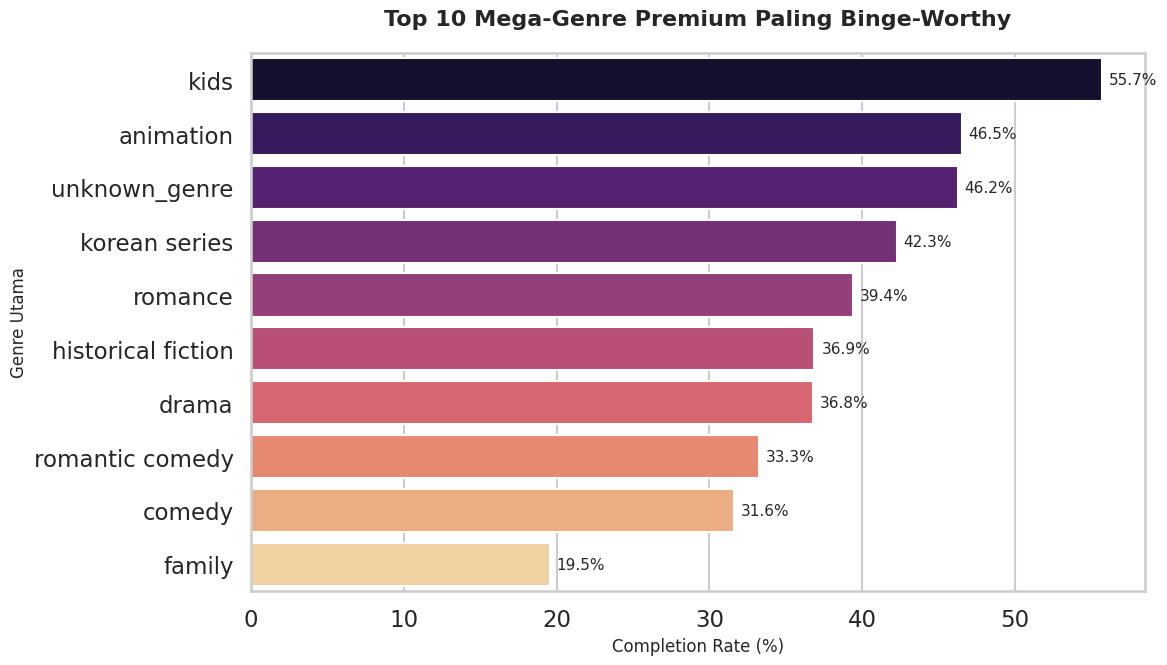

In [ ]:
top_10_premium = df_premium.head(10)

plt.figure(figsize=(12, 7))
ax = sns.barplot(data=top_10_premium, x='Completion Rate (%)', y='genre_name', palette='magma')

plt.title('Top 10 Mega-Genre Premium Paling Binge-Worthy', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Completion Rate (%)', fontsize=12)
plt.ylabel('Genre Utama', fontsize=12)

for p in ax.patches:
    ax.annotate(f"{p.get_width():.1f}%",
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
df_free.head(10)

,is_premium,content_type,genre_name,Total_Plays,Total_Completed,Completion Rate (%)
0,0,vod,science fiction,2828,1284.0,45.40
1,0,vod,indonesian movie,3434,1557.0,45.34
2,0,vod,comedy,289589,108092.0,37.33
3,0,vod,thriller,4733,1737.0,36.70
4,0,vod,romance,328136,116740.0,35.58
5,0,vod,action,6478,2113.0,32.62
6,0,vod,sinetron,1833156,492931.0,26.89
7,0,vod,unknown_genre,30901045,7800480.0,25.24
8,0,vod,music,50883,12829.0,25.21
9,0,vod,drama,195145,44322.0,22.71


/tmp/ipython-input-179/2380497341.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_10_free, x='Completion Rate (%)', y='genre_name', palette='magma')


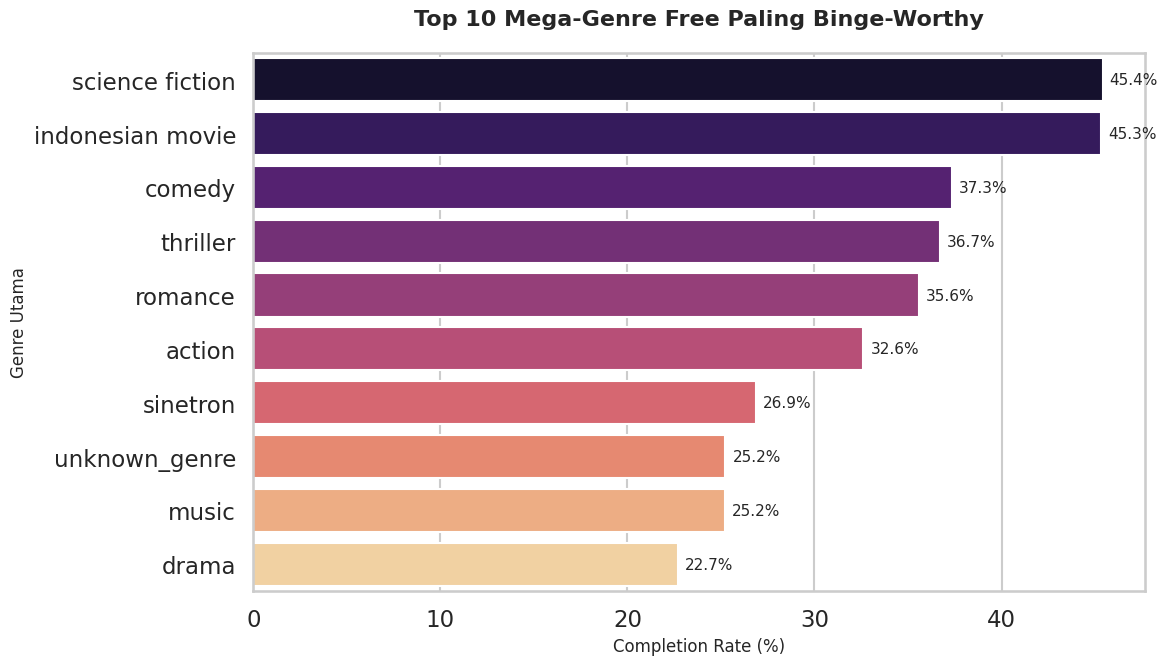

In [ ]:
top_10_free = df_free.head(10)

plt.figure(figsize=(12, 7))
ax = sns.barplot(data=top_10_free, x='Completion Rate (%)', y='genre_name', palette='magma')

plt.title('Top 10 Mega-Genre Free Paling Binge-Worthy', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Completion Rate (%)', fontsize=12)
plt.ylabel('Genre Utama', fontsize=12)

for p in ax.patches:
    ax.annotate(f"{p.get_width():.1f}%",
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=11)

plt.tight_layout()
plt.show()

### Business Insight

**Observasi**
- Di segmen **Premium (Berbayar)**, metrik penyelesaian tertinggi dikuasai secara mutlak oleh konten anak-anak dan keluarga. Genre `kids` menduduki puncak dengan *Completion Rate* 55.7%, disusul oleh `animation` di 46.5%. Selain itu, `korean series` juga menunjukkan tingkat *binge-watching* yang sangat solid di angka 42.3%.
- Di sisi lain, segmen **Free (Gratis)** memiliki demografi selera yang sama sekali berbeda. Pengguna gratis paling banyak menamatkan konten bergenre `science fiction` (45.4%) dan konten lokal `indonesian movie` (45.3%), disusul oleh genre *adrenaline-driven* seperti `thriller dan action`.

**Inisght**
- Tingginya angka penyelesaian pada genre `kids` dan `animation` membuktikan bahwa salah satu pendorong utama retensi langganan Premium adalah Orang Tua. Mereka memutar konten Premium untuk anak-anak mereka karena bebas iklan (aman) dan anak-anak memiliki kecenderungan menonton film animasi yang sama berulang kali hingga tamat.
- Tingkat penyelesaian `korean series` yang mencapai >40% membuktikan bahwa penggemar Drakor adalah audiens loyal yang bersedia membayar dan mendedikasikan waktu panjang untuk menonton marathon.
- Pengguna gratis sangat menyukai film Indonesia dan sinetron. Ini adalah konten *Top-of-Funnel* (pintu masuk) yang sangat baik karena memiliki daya tarik kultural yang luas dan mudah dinikmati oleh masyarakat umum.

**Rekomendasi**
1. Pertahankan dan perbanyak lisensi untuk konten `kids`, `animation`, dan `korean series` di tier Premium. Ketiga genre ini adalah "Pilar Retensi" yang menjaga agar pelanggan tidak membatalkan langganannya (churn).
2. Gunakan film Indonesia (`indonesian movie`) dan Sinetron yang sedang *hits* sebagai alat konversi. Karena penonton gratis sangat suka menamatkannya, OTT bisa menerapkan strategi *Paywall*: "Tonton 3 episode pertama gratis, berlangganan Premium untuk episode selanjutnya tanpa iklan."
3. Pertimbangkan untuk memperkuat fitur "***Kids Profile***" yang terpisah untuk pelanggan Premium. Dengan profil khusus anak yang UI-nya ramah anak, nilai jual langganan Premium OTT bagi keluarga akan semakin tidak tergantikan.

## 5. Platform Loyalty & Engagement Depth
**Pertanyaan Bisnis:** Di platform atau OS ekosistem mana audiens OTT memiliki tingkat loyalitas dan dedikasi waktu menonton (*stickiness*) terbaik?
* Fokus Metrik: `platform`, `Total Plays`, `Average Duration`, `Completion Rate (%)`.

In [ ]:
platform_total_plays = []
platform_total_completed = []
platform_total_duration = []

for i, chunk in enumerate(pd.read_csv(file_path, chunksize=chunk_size, on_bad_lines='skip', low_memory=False)):
  print(f"processed chunk-{i+1}")

  chunk = chunk.dropna(subset='platform')
  if chunk.empty: continue

  chunk['play_duration'] = pd.to_numeric(chunk['play_duration'], errors='coerce')
  chunk = chunk[chunk['play_duration'] > 0]

  chunk['completed'] = chunk['completed'].astype(str).str.lower()
  chunk['completed'] = chunk['completed'].map({'true': 1, 'false': 0}).fillna(0)

  platform_total_plays.append(chunk.groupby('platform')['hash_play_id'].count())
  platform_total_completed.append(chunk.groupby('platform')['completed'].sum())
  platform_total_duration.append(chunk.groupby('platform')['play_duration'].sum())

print("Chunking process completed")


processed chunk-1
processed chunk-2
processed chunk-3
processed chunk-4
processed chunk-5
processed chunk-6
processed chunk-7
processed chunk-8
processed chunk-9
processed chunk-10
processed chunk-11
processed chunk-12
processed chunk-13
processed chunk-14
processed chunk-15
processed chunk-16
processed chunk-17
processed chunk-18
processed chunk-19
processed chunk-20
processed chunk-21
processed chunk-22
processed chunk-23
processed chunk-24
processed chunk-25
processed chunk-26
processed chunk-27
processed chunk-28
processed chunk-29


/tmp/ipython-input-179/4186433162.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk['play_duration'] = pd.to_numeric(chunk['play_duration'], errors='coerce')


processed chunk-30
processed chunk-31
processed chunk-32
processed chunk-33
processed chunk-34
processed chunk-35
processed chunk-36
processed chunk-37
processed chunk-38
processed chunk-39
processed chunk-40
processed chunk-41
processed chunk-42
processed chunk-43
processed chunk-44
processed chunk-45
processed chunk-46
processed chunk-47
processed chunk-48
processed chunk-49
processed chunk-50
processed chunk-51
processed chunk-52
processed chunk-53
processed chunk-54
processed chunk-55
processed chunk-56
processed chunk-57
processed chunk-58
processed chunk-59
processed chunk-60
processed chunk-61
processed chunk-62
processed chunk-63
processed chunk-64
processed chunk-65
processed chunk-66
processed chunk-67
processed chunk-68
processed chunk-69
processed chunk-70
processed chunk-71
processed chunk-72
processed chunk-73
processed chunk-74
processed chunk-75
processed chunk-76
processed chunk-77
processed chunk-78
processed chunk-79
processed chunk-80
processed chunk-81
processed ch

In [ ]:
df_platform = pd.DataFrame({
    'Total_Plays': pd.concat(platform_total_plays).groupby(level=0).sum(),
    'Total_Completed': pd.concat(platform_total_completed).groupby(level=0).sum(),
    'Total_Duration': pd.concat(platform_total_duration).groupby(level=0).sum()
}).reset_index()

In [ ]:
df_platform['Completion Rate (%)'] = np.round(df_platform['Total_Completed'] / df_platform['Total_Plays'] * 100, 2)
df_platform['Avg Duration (Minutes)'] = np.round(df_platform['Total_Duration'] / df_platform['Total_Plays'] / 60, 2)
df_platform_sorted = df_platform.sort_values(by=['Avg Duration (Minutes)', 'Completion Rate (%)'], ascending=False).reset_index(drop=True)
df_platform_sorted

,platform,Total_Plays,Total_Completed,Total_Duration,Completion Rate (%),Avg Duration (Minutes)
0,tv-android,2068528,35222.0,3.653635e+09,1.70,29.44
1,tv-tizen,444070,13328.0,5.871336e+08,3.00,22.04
2,app-ios,536926,62722.0,5.185774e+08,11.68,16.10
3,app-android,12772369,1325049.0,1.224554e+10,10.37,15.98
4,web-desktop,4053410,777436.0,3.576384e+09,19.18,14.71
5,tv-webos,247,55.0,9.008200e+04,22.27,6.08
6,web-mobile,22137891,6395149.0,4.132801e+09,28.89,3.11


/tmp/ipython-input-179/4151624666.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(df_platform_sorted, x='Avg Duration (Minutes)', y='platform', palette='coolwarm')


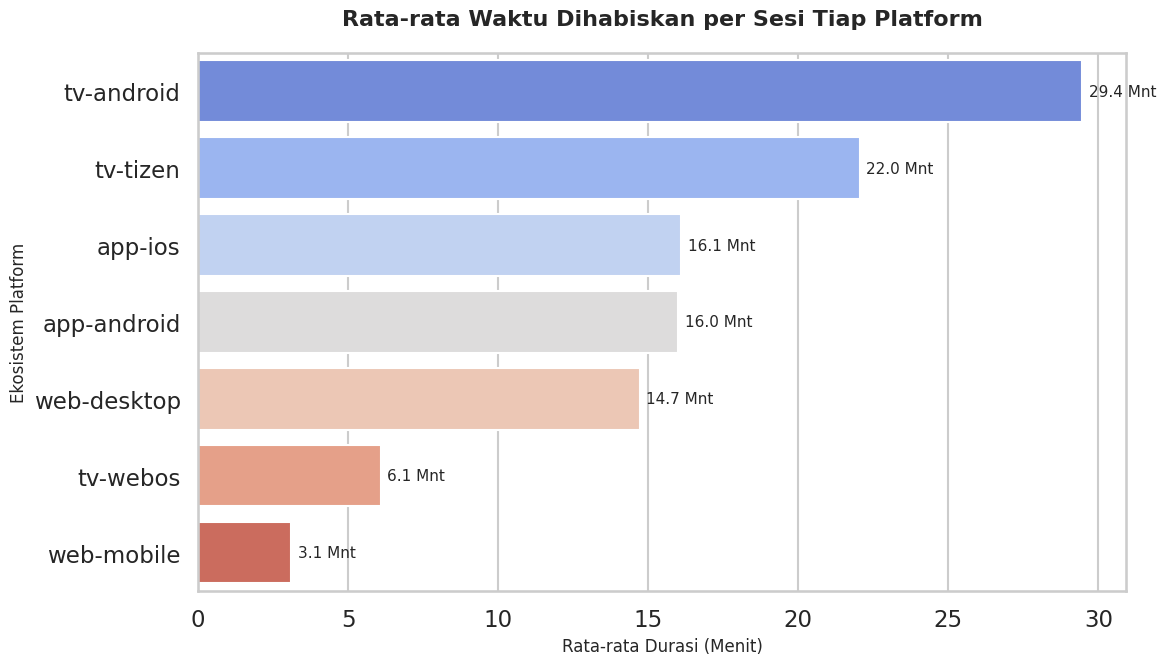

In [ ]:
plt.figure(figsize=(12, 7))

ax = sns.barplot(df_platform_sorted, x='Avg Duration (Minutes)', y='platform', palette='coolwarm')

plt.title('Rata-rata Waktu Dihabiskan per Sesi Tiap Platform', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Rata-rata Durasi (Menit)', fontsize=12)
plt.ylabel('Ekosistem Platform', fontsize=12)

for p in ax.patches:
    ax.annotate(f"{p.get_width():.1f} Mnt",
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=11)

plt.tight_layout()
plt.show()

### Business Insight

**Observasi**
- Ekosistem **Smart TV** (`tv-android` dan `tv-tizen`) mendominasi kedalaman *engagement*, di mana penonton menghabiskan waktu rata-rata **22 hingga nyaris 30 menit** per sesinya.
- Ekosistem **Aplikasi Mobile** (`app-ios` dan `app-android`) menunjukkan tingkat loyalitas yang sangat solid dan konsisten di angka ~**16 menit** per sesi.
- Sebaliknya, `web-mobile` menempati posisi paling dasar dengan rata-rata waktu tonton tersingkat, yaitu hanya **3.1 menit**.

**Insight**
- Pengguna di **Smart TV** memiliki intensi menonton *lean-back* (bersandar di sofa untuk menonton film panjang atau *live sports*). Ini adalah audiens paling premium. Sementara itu, Aplikasi Mobile adalah "ruang personal" audiens dengan retensi yang sangat kuat.
- Meskipun `web-mobile` sering kali memiliki volume kunjungan tertinggi (karena klik dari link WhatsApp atau Instagram), platform ini bukanlah tempat audiens loyal menetap. Mereka datang untuk menonton klip singkat lalu pergi.

**Rekomendasi**
1. Karena metrik membuktikan bahwa memindahkan *user* dari *Web *ke *App* akan meningkatkan *Watch Time* hingga **5x lipat** (dari 3 menit menjadi 16 menit), tim Product harus memperkuat *funnel konversi*. Terapkan banner "Lanjutkan Menonton di Aplikasi" secara agresif di `Web-Mobile`.
2. Tim Ads/Monetization harus memfokuskan penempatan iklan Mid-roll (iklan di tengah video) pada platform Aplikasi dan Smart TV, karena audiens di sana memiliki dedikasi waktu yang cukup panjang untuk menoleransi jeda iklan tanpa langsung *churn* (kabur).